In [ ]:
!pip install transformers datasets accelerate -q

In [ ]:
import torch
print(f"PyTorch version: {torch.__version__}")
print(f"GPU available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU name: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.11.0+cu128
GPU available: True
GPU name: Tesla T4


In [ ]:
from datasets import load_dataset

dataset = load_dataset("DGurgurov/urdu_sa")
print(dataset)

README.md:   0%|          | 0.00/1.83k [00:00<?, ?B/s]

train.csv: reconstructing file:   0%|          |  0.00B / 15.5MB            

train.csv: downloading bytes:           |  0.00B            

dev.csv:   0%|          | 0.00/3.84M [00:00<?, ?B/s]

test.csv:   0%|          | 0.00/3.73M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/7356 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1811 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1812 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 7356
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 1811
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 1812
    })
})


In [ ]:
import pandas as pd


df_train = dataset['train'].to_pandas()
print(f"Columns: {df_train.columns.tolist()}")
print(f"Shape: {df_train.shape}")
print(f"\nLabel distribution:\n{df_train['label'].value_counts()}")
print(f"\nFirst 3 rows:")
df_train.head(3)

Columns: ['text', 'label']
Shape: (7356, 2)

Label distribution:
label
1    3718
0    3638
Name: count, dtype: int64

First 3 rows:


,text,label
0,خراب کرنے والوں پر مشتمل ہوسکتا ہے۔ یہ صرف ایک...,1
1,"میں نے براڈوے پر اصل ""کورسس لائن"" دیکھا خدا جا...",0
2,'وار مووی' ہالی ووڈ کی ایک صنف ہے جو کئی بار ہ...,1


In [ ]:
df_train = dataset['train'].to_pandas()
df_val = dataset['validation'].to_pandas()
df_test = dataset['test'].to_pandas()

In [ ]:
print("=" * 50)
print("DATASET OVERVIEW")
print("=" * 50)
print(f"Training samples:   {len(df_train)}")
print(f"Validation samples: {len(df_val)}")
print(f"Test samples:       {len(df_test)}")
print(f"Total samples:      {len(df_train) + len(df_val) + len(df_test)}")
print(f"\nColumns: {df_train.columns.tolist()}")
print(f"Label dtype: {df_train['label'].dtype}")
print(f"Unique labels: {sorted(df_train['label'].unique())}")

DATASET OVERVIEW
Training samples:   7356
Validation samples: 1811
Test samples:       1812
Total samples:      10979

Columns: ['text', 'label']
Label dtype: int64
Unique labels: [np.int64(0), np.int64(1)]


In [ ]:
print("=" * 50)
print("LABEL DISTRIBUTION")
print("=" * 50)

for name, df in [("Train", df_train), ("Validation", df_val), ("Test", df_test)]:
    counts = df['label'].value_counts().sort_index()
    total = len(df)
    print(f"\n{name} set:")
    for label, count in counts.items():
        pct = count / total * 100
        print(f"  Label {label}: {count} ({pct:.1f}%)")

LABEL DISTRIBUTION

Train set:
  Label 0: 3638 (49.5%)
  Label 1: 3718 (50.5%)

Validation set:
  Label 0: 875 (48.3%)
  Label 1: 936 (51.7%)

Test set:
  Label 0: 904 (49.9%)
  Label 1: 908 (50.1%)


In [ ]:
print("=" * 50)
print("DATA QUALITY CHECKS")
print("=" * 50)

for name, df in [("Train", df_train), ("Validation", df_val), ("Test", df_test)]:
    missing_text = df['text'].isna().sum()
    missing_label = df['label'].isna().sum()
    empty_text = (df['text'].str.strip() == '').sum()
    duplicates = df.duplicated(subset=['text']).sum()

    print(f"\n{name} set:")
    print(f"  Missing text:   {missing_text}")
    print(f"  Missing labels: {missing_label}")
    print(f"  Empty text:     {empty_text}")
    print(f"  Duplicate text: {duplicates}")


train_texts = set(df_train['text'].tolist())
val_texts = set(df_val['text'].tolist())
test_texts = set(df_test['text'].tolist())

train_val_overlap = len(train_texts & val_texts)
train_test_overlap = len(train_texts & test_texts)
val_test_overlap = len(val_texts & test_texts)

print(f"\nCROSS-SPLIT OVERLAP (data leakage check):")
print(f"  Train ∩ Validation: {train_val_overlap}")
print(f"  Train ∩ Test:       {train_test_overlap}")
print(f"  Validation ∩ Test:  {val_test_overlap}")

DATA QUALITY CHECKS

Train set:
  Missing text:   0
  Missing labels: 0
  Empty text:     0
  Duplicate text: 10

Validation set:
  Missing text:   0
  Missing labels: 0
  Empty text:     0
  Duplicate text: 0

Test set:
  Missing text:   0
  Missing labels: 0
  Empty text:     0
  Duplicate text: 1

CROSS-SPLIT OVERLAP (data leakage check):
  Train ∩ Validation: 6
  Train ∩ Test:       5
  Validation ∩ Test:  2


In [ ]:
print("=" * 50)
print("TEXT LENGTH STATISTICS (characters)")
print("=" * 50)

for name, df in [("Train", df_train), ("Validation", df_val), ("Test", df_test)]:
    lengths = df['text'].str.len()
    print(f"\n{name} set:")
    print(f"  Min:    {lengths.min()}")
    print(f"  Max:    {lengths.max()}")
    print(f"  Mean:   {lengths.mean():.1f}")
    print(f"  Median: {lengths.median():.1f}")

long_texts = (df_train['text'].str.len() > 512).sum()
pct_long = long_texts / len(df_train) * 100
print(f"\nTexts longer than 512 chars: {long_texts} ({pct_long:.1f}%)")
print("(These will likely be truncated at 128 tokens)")

TEXT LENGTH STATISTICS (characters)

Train set:
  Min:    11
  Max:    8613
  Mean:   1193.9
  Median: 899.0

Validation set:
  Min:    8
  Max:    6004
  Mean:   1203.0
  Median: 909.0

Test set:
  Min:    21
  Max:    12062
  Mean:   1167.3
  Median: 895.0

Texts longer than 512 chars: 6004 (81.6%)
(These will likely be truncated at 128 tokens)


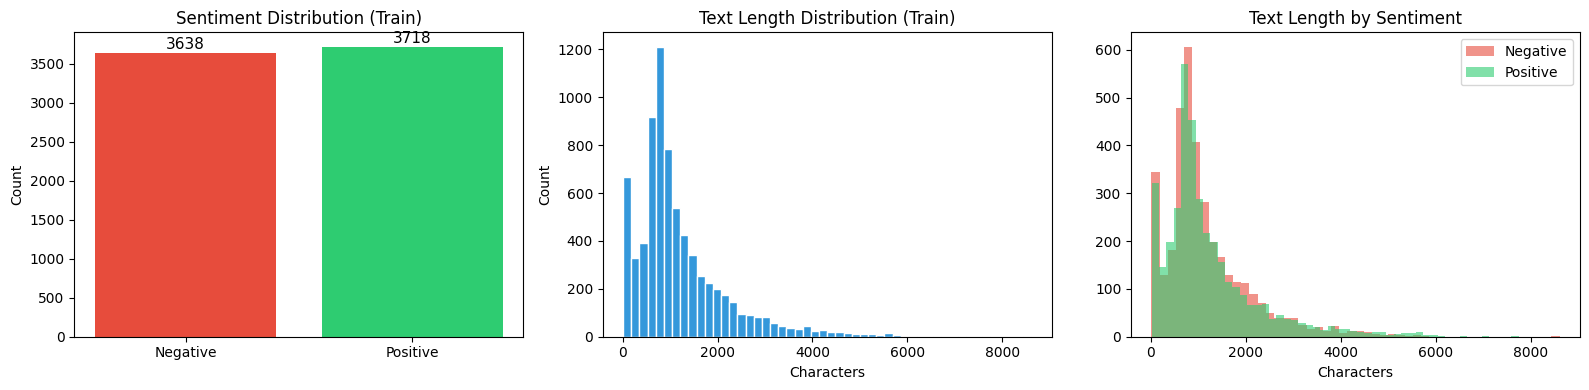

Saved: eda_visualizations.png


In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Plot 1: Sentiment distribution
label_names = {0: 'Negative', 1: 'Positive'}
train_counts = df_train['label'].value_counts().sort_index()
colors = ['#e74c3c', '#2ecc71']

bars = axes[0].bar(
    [label_names[l] for l in train_counts.index],
    train_counts.values,
    color=colors
)
axes[0].set_title('Sentiment Distribution (Train)')
axes[0].set_ylabel('Count')
for bar, count in zip(bars, train_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 str(count), ha='center', fontsize=11)

axes[1].hist(df_train['text'].str.len(), bins=50, color='#3498db', edgecolor='white')
axes[1].set_title('Text Length Distribution (Train)')
axes[1].set_xlabel('Characters')
axes[1].set_ylabel('Count')

for label, color, name in [(0, '#e74c3c', 'Negative'), (1, '#2ecc71', 'Positive')]:
    subset = df_train[df_train['label'] == label]['text'].str.len()
    axes[2].hist(subset, bins=50, alpha=0.6, color=color, label=name)
axes[2].set_title('Text Length by Sentiment')
axes[2].set_xlabel('Characters')
axes[2].legend()

plt.tight_layout()
plt.savefig('eda_visualizations.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: eda_visualizations.png")

In [ ]:
df_train = df_train.drop_duplicates(subset=['text'], keep='first').reset_index(drop=True)
df_val = df_val.drop_duplicates(subset=['text'], keep='first').reset_index(drop=True)
df_test = df_test.drop_duplicates(subset=['text'], keep='first').reset_index(drop=True)

In [ ]:
val_texts = set(df_val['text'].tolist())
test_texts = set(df_test['text'].tolist())

In [ ]:
leaked_mask = df_train['text'].isin(val_texts | test_texts)
leaked_count = leaked_mask.sum()
df_train = df_train[~leaked_mask].reset_index(drop=True)

In [ ]:
print(f"\nAFTER CLEANING:")
print(f"  Train: {len(df_train)}, Val: {len(df_val)}, Test: {len(df_test)}")


AFTER CLEANING:
  Train: 7335, Val: 1811, Test: 1811


In [ ]:
train_texts_clean = set(df_train['text'].tolist())
val_texts_clean = set(df_val['text'].tolist())
test_texts_clean = set(df_test['text'].tolist())

In [ ]:
print(f"\nVERIFICATION (should all be 0):")
print(f"  Train ∩ Validation: {len(train_texts_clean & val_texts_clean)}")
print(f"  Train ∩ Test:       {len(train_texts_clean & test_texts_clean)}")
print(f"  Validation ∩ Test:  {len(val_texts_clean & test_texts_clean)}")


VERIFICATION (should all be 0):
  Train ∩ Validation: 0
  Train ∩ Test:       0
  Validation ∩ Test:  2


In [ ]:
test_texts_set = set(df_test['text'].tolist())
val_test_leaked = df_val['text'].isin(test_texts_set)
removed_count = val_test_leaked.sum()
df_val = df_val[~val_test_leaked].reset_index(drop=True)

print(f"Removed {removed_count} overlapping texts from validation")
print(f"Validation size now: {len(df_val)}")

train_texts_final = set(df_train['text'].tolist())
val_texts_final = set(df_val['text'].tolist())
test_texts_final = set(df_test['text'].tolist())

print(f"\nFINAL VERIFICATION (must all be 0):")
print(f"  Train ∩ Validation: {len(train_texts_final & val_texts_final)}")
print(f"  Train ∩ Test:       {len(train_texts_final & test_texts_final)}")
print(f"  Validation ∩ Test:  {len(val_texts_final & test_texts_final)}")

Removed 2 overlapping texts from validation
Validation size now: 1809

FINAL VERIFICATION (must all be 0):
  Train ∩ Validation: 0
  Train ∩ Test:       0
  Validation ∩ Test:  0


<h1>building pipeline----cleaning dataset
</h1>

In [ ]:
import re

def inspect_noise(df, sample_size=None):
    """
    Scan the dataset for common types of noise.

    Why this function exists: instead of guessing what
    needs cleaning, we measure it. This prevents us from
    writing unnecessary code or missing real problems.
    """
    texts = df['text'] if sample_size is None else df['text']

    has_url = texts.str.contains(r'http[s]?://\S+|www\.\S+', regex=True).sum()
    has_html = texts.str.contains(r'<[^>]+>', regex=True).sum()
    has_mention = texts.str.contains(r'@\w+', regex=True).sum()
    has_hashtag = texts.str.contains(r'#\w+', regex=True).sum()
    has_extra_spaces = texts.str.contains(r'\s{2,}', regex=True).sum()
    has_newlines = texts.str.contains(r'\n', regex=True).sum()

    total = len(texts)
    print(f"Noise analysis ({total} texts):")
    print(f"  URLs:           {has_url} ({has_url/total*100:.1f}%)")
    print(f"  HTML tags:      {has_html} ({has_html/total*100:.1f}%)")
    print(f"  @mentions:      {has_mention} ({has_mention/total*100:.1f}%)")
    print(f"  #hashtags:      {has_hashtag} ({has_hashtag/total*100:.1f}%)")
    print(f"  Extra spaces:   {has_extra_spaces} ({has_extra_spaces/total*100:.1f}%)")
    print(f"  Newlines:       {has_newlines} ({has_newlines/total*100:.1f}%)")

inspect_noise(df_train)

Noise analysis (7335 texts):
  URLs:           18 (0.2%)
  HTML tags:      3 (0.0%)
  @mentions:      7 (0.1%)
  #hashtags:      0 (0.0%)
  Extra spaces:   0 (0.0%)
  Newlines:       0 (0.0%)


In [ ]:
noise_patterns = {
    'URL': r'http[s]?://\S+|www\.\S+',
    'HTML': r'<[^>]+>',
    '@mention': r'@\w+',
    'Extra spaces': r'\s{3,}',
}

for noise_name, pattern in noise_patterns.items():
    matches = df_train[df_train['text'].str.contains(pattern, regex=True)]
    if len(matches) > 0:
        print(f"\n{'─' * 40}")
        print(f"Example of {noise_name}:")
        print(f"{'─' * 40}")
        sample_text = matches.iloc[0]['text']
        match = re.search(pattern, sample_text)
        if match:
            start = max(0, match.start() - 50)
            end = min(len(sample_text), match.end() + 50)
            print(f"...{sample_text[start:end]}...")
    else:
        print(f"\n{noise_name}: No examples found in training data")


────────────────────────────────────────
Example of URL:
────────────────────────────────────────
...مباحثے کا مشاہدہ کریں۔ یا ، انتہائی حد تک ، مقالہ www.mjyoung.net/time/monkeys.html پر دیکھیں۔ واہ! مصنفین ڈیوڈ اور جینٹ پیپلیس کے کر...

────────────────────────────────────────
Example of HTML:
────────────────────────────────────────
...بھی ہے - تاریخ نہیں معلوم - انتظار نہیں کرسکتا! ! <<<< >>>> ذیل میں میرا اصل تبصرہ ہے <<<<< میں دوسرے تمام...

────────────────────────────────────────
Example of @mention:
────────────────────────────────────────
...ے کہاں سے تلاش کرسکتا ہوں؟ میری ای میل cristin6891@aim.com ہے برائے مہربانی مجھے ای میل کریں اگر آپ جانت...

Extra spaces: No examples found in training data


In [ ]:
import re

def preprocess_text(text):
    #handling non-string or empty input
    if not isinstance(text, str) or not text.strip():
        return ""

    #Removing URLs (http:// and www.)
    text = re.sub(r'http[s]?://\S+', '', text)
    text = re.sub(r'www\.\S+', '', text)

    # the at-sign regex would mangle the email
    text = re.sub(r'\S+@\S+\.\S+', '', text)

    # Step 3: Replace remaining at-mentions with a generic token
    # Why replace instead of delete? Removing a mention from
    # a sentence changes its grammatical structure.
    # Replacing preserves grammar while removing the
    # irrelevant username
    text = re.sub(r'@\w+', '@user', text)

    # Step 4: Remove only well-formed HTML tags like <br/>, <p>, <b>
    # Why this specific pattern instead of the broad <[^>]+> ?
    # Because reviewers use <<<< and >>>> as decoration.
    # The broad pattern would delete actual content.
    # This only matches tags starting with a letter.
    text = re.sub(r'</?[a-zA-Z][^>]*>', '', text)

    # Step 5: Normalize whitespace
    # After removing URLs/emails, double spaces may remain.
    # This converts all whitespace to single spaces.
    text = re.sub(r'\s+', ' ', text)

    # Step 6: Strip leading/trailing whitespace
    text = text.strip()

    return text

In [ ]:
test_cases = [
    ("اچھی فلم ہے https://example.com دیکھیں",
     "URL removal"),

    ("مقالہ www.mjyoung.net/time/monkeys.html پر دیکھیں",
     "www-style URL removal"),

    ("میری ای میل cristin6891@aim.com ہے",
     "Email removal"),

    ("بہت اچھا <br/> شاندار <b>فلم</b>",
     "Real HTML tag removal"),

    ("<<<< >>>> ذیل میں میرا تبصرہ ہے <<<<<",
     "Decorative arrows should survive"),

    ("عام اردو جملہ بغیر کسی شور کے",
     "Clean text should stay unchanged"),

    ("", "Empty string"),

    ("   ", "Only whitespace"),
]

print("PREPROCESSING TEST RESULTS:")
print("=" * 60)
for text, test_name in test_cases:
    result = preprocess_text(text)
    print(f"\nTest: {test_name}")
    print(f"  Input:  '{text}'")
    print(f"  Output: '{result}'")


PREPROCESSING TEST RESULTS:

Test: URL removal
  Input:  'اچھی فلم ہے https://example.com دیکھیں'
  Output: 'اچھی فلم ہے دیکھیں'

Test: www-style URL removal
  Input:  'مقالہ www.mjyoung.net/time/monkeys.html پر دیکھیں'
  Output: 'مقالہ پر دیکھیں'

Test: Email removal
  Input:  'میری ای میل cristin6891@aim.com ہے'
  Output: 'میری ای میل ہے'

Test: Real HTML tag removal
  Input:  'بہت اچھا <br/> شاندار <b>فلم</b>'
  Output: 'بہت اچھا شاندار فلم'

Test: Decorative arrows should survive
  Input:  '<<<< >>>> ذیل میں میرا تبصرہ ہے <<<<<'
  Output: '<<<< >>>> ذیل میں میرا تبصرہ ہے <<<<<'

Test: Clean text should stay unchanged
  Input:  'عام اردو جملہ بغیر کسی شور کے'
  Output: 'عام اردو جملہ بغیر کسی شور کے'

Test: Empty string
  Input:  ''
  Output: ''

Test: Only whitespace
  Input:  '   '
  Output: ''


In [ ]:
print("Applying preprocessing...")

for name, df in [("Train", df_train), ("Validation", df_val), ("Test", df_test)]:
    # Apply the cleaning function to every text
    df['text'] = df['text'].apply(preprocess_text)

    # Count texts that became empty after cleaning
    empty_after = (df['text'] == '').sum()

    print(f"  {name}: {len(df)} texts processed, {empty_after} became empty")

# Remove any rows that became empty
before = len(df_train) + len(df_val) + len(df_test)

df_train = df_train[df_train['text'] != ''].reset_index(drop=True)
df_val = df_val[df_val['text'] != ''].reset_index(drop=True)
df_test = df_test[df_test['text'] != ''].reset_index(drop=True)

after = len(df_train) + len(df_val) + len(df_test)

if before - after > 0:
    print(f"\nRemoved {before - after} empty texts")
else:
    print("\nNo texts lost — all data preserved")

print(f"Final sizes — Train: {len(df_train)}, Val: {len(df_val)}, Test: {len(df_test)}")

Applying preprocessing...
  Train: 7335 texts processed, 0 became empty
  Validation: 1809 texts processed, 0 became empty
  Test: 1811 texts processed, 0 became empty

No texts lost — all data preserved
Final sizes — Train: 7335, Val: 1809, Test: 1811


In [ ]:
from transformers import AutoTokenizer

model_name = "xlm-roberta-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)

print(f"Tokenizer loaded: {model_name}")
print(f"Vocabulary size: {tokenizer.vocab_size}")

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

Tokenizer loaded: xlm-roberta-base
Vocabulary size: 250002


In [ ]:
sample_text = "یہ بہت اچھی فلم ہے"
print(f"Original text: {sample_text}\n")

encoded = tokenizer(sample_text)
print(f"Token IDs: {encoded['input_ids']}")
print(f"Attention mask: {encoded['attention_mask']}")

tokens = tokenizer.convert_ids_to_tokens(encoded['input_ids'])
print(f"Subword tokens: {tokens}")

print(f"\nNumber of tokens: {len(encoded['input_ids'])}")
print(f"Number of characters: {len(sample_text)}")

Original text: یہ بہت اچھی فلم ہے

Token IDs: [0, 1938, 10494, 102239, 16770, 639, 2]
Attention mask: [1, 1, 1, 1, 1, 1, 1]
Subword tokens: ['<s>', '▁یہ', '▁بہت', '▁اچھی', '▁فلم', '▁ہے', '</s>']

Number of tokens: 7
Number of characters: 18


In [ ]:
real_text = df_train['text'].iloc[0]
print(f"Text length: {len(real_text)} characters")
print(f"First 200 chars: {real_text[:200]}...\n")

full_tokens = tokenizer(real_text)
print(f"Tokens without limit: {len(full_tokens['input_ids'])}")

# Tokenizing WITH our 256 token limit
limited_tokens = tokenizer(
    real_text,
    max_length=256,
    truncation=True
)
print(f"Tokens with 256 limit: {len(limited_tokens['input_ids'])}")

kept_pct = len(limited_tokens['input_ids']) / len(full_tokens['input_ids']) * 100
print(f"Text retained: {kept_pct:.1f}%")


Text length: 742 characters
First 200 chars: خراب کرنے والوں پر مشتمل ہوسکتا ہے۔ یہ صرف ایک اچھی فلم ہے۔ ہنسنے کے لئے بہت ساری اچھی بیوقوف چیزیں۔ تاہم ، ٹی وی ورژن نہ دیکھیں ، وہ بہت کم ہوگئے۔ ڈوم ڈیلائوس مافیا ڈان کی طرح حیرت انگیز ہے جسے روبین...

Tokens without limit: 214
Tokens with 256 limit: 214
Text retained: 100.0%


In [ ]:
longest_idx = df_train['text'].str.len().idxmax()
long_text = df_train['text'].iloc[longest_idx]

print(f"Longest review: {len(long_text)} characters\n")

full_tokens = tokenizer(long_text)
print(f"Tokens without limit: {len(full_tokens['input_ids'])}")


limited_tokens = tokenizer(long_text, max_length=256, truncation=True)
print(f"Tokens with 256 limit: {len(limited_tokens['input_ids'])}")

kept_pct = len(limited_tokens['input_ids']) / len(full_tokens['input_ids']) * 100
print(f"Text retained: {kept_pct:.1f}%")


median_len = df_train['text'].str.len().median()
median_idx = (df_train['text'].str.len() - median_len).abs().idxmin()
median_text = df_train['text'].iloc[median_idx]

full_median = tokenizer(median_text)
limited_median = tokenizer(median_text, max_length=256, truncation=True)
median_pct = len(limited_median['input_ids']) / len(full_median['input_ids']) * 100

print(f"\nMedian-length review: {len(median_text)} characters")
print(f"Tokens without limit: {len(full_median['input_ids'])}")
print(f"Tokens with 256 limit: {len(limited_median['input_ids'])}")
print(f"Text retained: {median_pct:.1f}%")

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (2502 > 512). Running this sequence through the model will result in indexing errors


Longest review: 8613 characters

Tokens without limit: 2502
Tokens with 256 limit: 256
Text retained: 10.2%

Median-length review: 899 characters
Tokens without limit: 262
Tokens with 256 limit: 256
Text retained: 97.7%


In [ ]:

token_counts = []
for text in df_train['text']:
    tokens = tokenizer(text)
    token_counts.append(len(tokens['input_ids']))

import pandas as pd

token_series = pd.Series(token_counts)
fits_in_256 = (token_series <= 256).sum()
fits_pct = fits_in_256 / len(token_series) * 100

print(f"Total training texts: {len(token_series)}")
print(f"Texts that fit in 256 tokens: {fits_in_256} ({fits_pct:.1f}%)")
print(f"\nToken count statistics:")
print(f"  Min:    {token_series.min()}")
print(f"  Max:    {token_series.max()}")
print(f"  Mean:   {token_series.mean():.1f}")
print(f"  Median: {token_series.median():.1f}")

Total training texts: 7335
Texts that fit in 256 tokens: 3665 (50.0%)

Token count statistics:
  Min:    5
  Max:    2502
  Mean:   342.3
  Median: 257.0


In [ ]:

for max_len in [256, 384, 512]:
    fits = (token_series <= max_len).sum()
    pct = fits / len(token_series) * 100
    print(f"Max {max_len} tokens: {fits}/{len(token_series)} texts fit ({pct:.1f}%)")

Max 256 tokens: 3665/7335 texts fit (50.0%)
Max 384 tokens: 5142/7335 texts fit (70.1%)
Max 512 tokens: 5934/7335 texts fit (80.9%)


In [ ]:

MAX_LENGTH = 384
MODEL_NAME = "xlm-roberta-base"

print("TOKENIZATION CONFIGURATION:")
print(f"  Model:          {MODEL_NAME}")
print(f"  Max length:     {MAX_LENGTH} tokens")
print(f"  Truncation:     Enabled (texts longer than {MAX_LENGTH} will be cut)")
print(f"  Padding:        Will be applied during batching")
print(f"  Text coverage:  ~70% of texts fit fully")

TOKENIZATION CONFIGURATION:
  Model:          xlm-roberta-base
  Max length:     384 tokens
  Truncation:     Enabled (texts longer than 384 will be cut)
  Padding:        Will be applied during batching
  Text coverage:  ~70% of texts fit fully


In [ ]:
from datasets import Dataset

train_dataset = Dataset.from_pandas(df_train)
val_dataset = Dataset.from_pandas(df_val)
test_dataset = Dataset.from_pandas(df_test)

def tokenize_function(examples):
    return tokenizer(
        examples['text'],
        max_length=MAX_LENGTH,
        truncation=True,
        padding=False
    )

print("Tokenizing training set...")
train_dataset = train_dataset.map(tokenize_function, batched=True)

print("Tokenizing validation set...")
val_dataset = val_dataset.map(tokenize_function, batched=True)

print("Tokenizing test set...")
test_dataset = test_dataset.map(tokenize_function, batched=True)

print(f"\nDone! Training set columns: {train_dataset.column_names}")
print(f"First example keys: {list(train_dataset[0].keys())}")

Tokenizing training set...


Map:   0%|          | 0/7335 [00:00<?, ? examples/s]

Tokenizing validation set...


Map:   0%|          | 0/1809 [00:00<?, ? examples/s]

Tokenizing test set...


Map:   0%|          | 0/1811 [00:00<?, ? examples/s]


Done! Training set columns: ['text', 'label', 'input_ids', 'attention_mask']
First example keys: ['text', 'label', 'input_ids', 'attention_mask']


In [ ]:
example = train_dataset[0]

print("TOKENIZATION VERIFICATION:")
print(f"  Original text (first 100 chars): {example['text'][:100]}...")
print(f"  Label: {example['label']}")
print(f"  Number of tokens: {len(example['input_ids'])}")
print(f"  First 10 token IDs: {example['input_ids'][:10]}")
print(f"  Attention mask (first 10): {example['attention_mask'][:10]}")

decoded = tokenizer.decode(example['input_ids'], skip_special_tokens=True)
print(f"\n  Decoded back (first 100 chars): {decoded[:100]}...")

TOKENIZATION VERIFICATION:
  Original text (first 100 chars): خراب کرنے والوں پر مشتمل ہوسکتا ہے۔ یہ صرف ایک اچھی فلم ہے۔ ہنسنے کے لئے بہت ساری اچھی بیوقوف چیزیں۔...
  Label: 1
  Number of tokens: 214
  First 10 token IDs: [0, 45812, 3210, 38166, 523, 102260, 200834, 1633, 1938, 8777]
  Attention mask (first 10): [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]

  Decoded back (first 100 chars): خراب کرنے والوں پر مشتمل ہوسکتا ہے۔ یہ صرف ایک اچھی فلم ہے۔ ہنسنے کے لئے بہت ساری اچھی بیوقوف چیزیں۔...


In [ ]:
from transformers import AutoModelForSequenceClassification

id2label = {0: "Negative", 1: "Positive"}
label2id = {"Negative": 0, "Positive": 1}

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    id2label=id2label,
    label2id=label2id
)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Model: {MODEL_NAME}")
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Classification labels: {id2label}")

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.12GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.bias       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model: xlm-roberta-base
Total parameters: 278,045,186
Trainable parameters: 278,045,186
Classification labels: {0: 'Negative', 1: 'Positive'}


In [ ]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./results",

    num_train_epochs=3,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,  # Can be larger since no gradients stored

    learning_rate=2e-5,

    weight_decay=0.01,

    eval_strategy="epoch",

   save_strategy="epoch",

    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    save_total_limit=2,  # Keep only 2 best checkpoints
    fp16=True,

    logging_steps=50,

    seed=42,
)

print("Training configuration set!")
print(f"  Epochs:         {training_args.num_train_epochs}")
print(f"  Batch size:     {training_args.per_device_train_batch_size}")
print(f"  Learning rate:  {training_args.learning_rate}")
print(f"  Weight decay:   {training_args.weight_decay}")
print(f"  Mixed precision: {training_args.fp16}")
print(f"  Seed:           {training_args.seed}")

Training configuration set!
  Epochs:         3
  Batch size:     8
  Learning rate:  2e-05
  Weight decay:   0.01
  Mixed precision: True
  Seed:           42


In [ ]:
from sklearn.metrics import accuracy_score, f1_score
import numpy as np

def compute_metrics(eval_pred):
    """
    This function runs automatically after each evaluation.
    The Trainer calls it and passes the model's predictions.

    eval_pred contains two things:
    - logits: raw model outputs (not yet probabilities)
    - labels: the correct answers

    Why argmax? The model outputs two numbers per text
    (one score for Negative, one for Positive). argmax
    picks whichever score is higher as the prediction.
    For example: [2.1, -0.5] → argmax → 0 → Negative
                 [-1.3, 3.7] → argmax → 1 → Positive
    """
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    accuracy = accuracy_score(labels, predictions)
    f1 = f1_score(labels, predictions, average='weighted')

    return {
        "accuracy": accuracy,
        "f1": f1
    }

print("Evaluation metrics function defined: accuracy and weighted F1")

Evaluation metrics function defined: accuracy and weighted F1


In [ ]:
from transformers import Trainer, DataCollatorWithPadding

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

print("Trainer ready. Starting training...")
print("This will take approximately 20-40 minutes.")
print("Do NOT close this tab or let your laptop sleep!\n")

train_result = trainer.train()

print("\nTraining complete!")

Trainer ready. Starting training...
This will take approximately 20-40 minutes.
Do NOT close this tab or let your laptop sleep!



Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.700445,0.693369,0.516860,0.352233
2,0.700206,0.693494,0.483140,0.314770
3,0.693794,0.692645,0.516860,0.352233


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Training complete!


In [ ]:
print("Train dataset columns:", train_dataset.column_names)
print("First example label:", train_dataset[0]['label'])
print("Label type:", type(train_dataset[0]['label']))

print("\nDoes 'labels' column exist?", 'labels' in train_dataset.column_names)
print("Does 'label' column exist?", 'label' in train_dataset.column_names)

Train dataset columns: ['text', 'label', 'input_ids', 'attention_mask']
First example label: 1
Label type: <class 'int'>

Does 'labels' column exist? False
Does 'label' column exist? True


In [ ]:
train_dataset = train_dataset.rename_column("label", "labels")
val_dataset = val_dataset.rename_column("label", "labels")
test_dataset = test_dataset.rename_column("label", "labels")

print("Columns after rename:", train_dataset.column_names)
print("First example labels:", train_dataset[0]['labels'])

Columns after rename: ['text', 'labels', 'input_ids', 'attention_mask']
First example labels: 1


In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    id2label=id2label,
    label2id=label2id
)

print("Fresh model loaded. Creating new Trainer...")

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

print("Starting training (this will take ~20-40 minutes)...")
print("Do NOT close this tab!\n")

train_result = trainer.train()

print("\nTraining complete!")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.bias       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Fresh model loaded. Creating new Trainer...
Starting training (this will take ~20-40 minutes)...
Do NOT close this tab!



Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.541068,0.515158,0.763958,0.758156


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.541068,0.515158,0.763958,0.758156
2,0.372144,0.405125,0.835821,0.835533
3,0.385725,0.543183,0.843007,0.842973


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Training complete!


In [ ]:
print("Evaluating on the held-out test set...")
predictions = trainer.predict(test_dataset)

print(f"\nTest Loss: {predictions.metrics['test_loss']:.4f}")
print(f"Test Accuracy: {predictions.metrics['test_accuracy']:.4f}")
print(f"Test F1: {predictions.metrics['test_f1']:.4f}")

Evaluating on the held-out test set...



Test Loss: 0.4089
Test Accuracy: 0.8294
Test F1: 0.8292


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

preds = np.argmax(predictions.predictions, axis=-1)
labels = predictions.label_ids

print("DETAILED CLASSIFICATION REPORT:")
print("=" * 55)
report = classification_report(
    labels,
    preds,
    target_names=["Negative", "Positive"]
)
print(report)

DETAILED CLASSIFICATION REPORT:
              precision    recall  f1-score   support

    Negative       0.85      0.80      0.82       904
    Positive       0.81      0.86      0.83       907

    accuracy                           0.83      1811
   macro avg       0.83      0.83      0.83      1811
weighted avg       0.83      0.83      0.83      1811



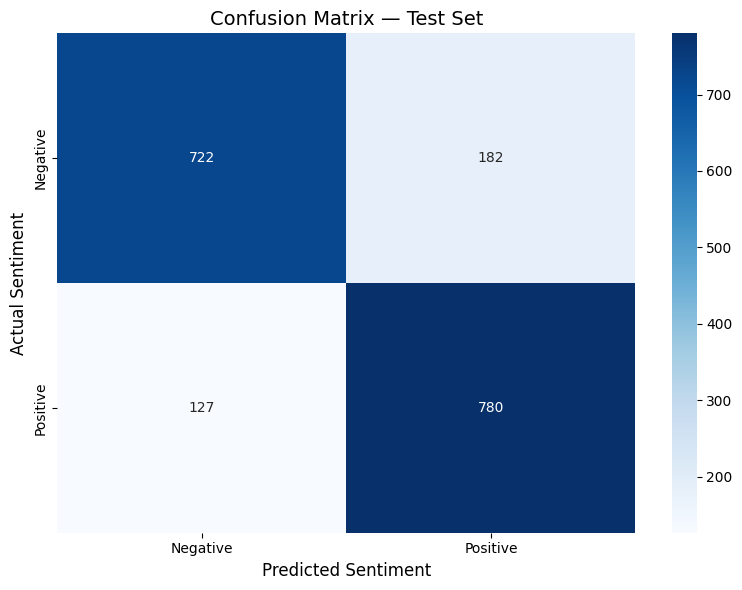


Correct predictions: 1502 / 1811
Negative correctly predicted: 722 / 904
Positive correctly predicted: 780 / 907

Saved: confusion_matrix.png


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(labels, preds)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)
plt.title('Confusion Matrix — Test Set', fontsize=14)
plt.ylabel('Actual Sentiment', fontsize=12)
plt.xlabel('Predicted Sentiment', fontsize=12)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nCorrect predictions: {cm[0][0] + cm[1][1]} / {len(labels)}")
print(f"Negative correctly predicted: {cm[0][0]} / {cm[0][0] + cm[0][1]}")
print(f"Positive correctly predicted: {cm[1][1]} / {cm[1][0] + cm[1][1]}")
print(f"\nSaved: confusion_matrix.png")


In [ ]:
import os

# Defining the save directory
save_dir = "./urdu_sentiment_model"

trainer.save_model(save_dir)
tokenizer.save_pretrained(save_dir)

print("Saved files:")
for f in os.listdir(save_dir):
    size = os.path.getsize(os.path.join(save_dir, f))
    size_mb = size / (1024 * 1024)
    print(f"  {f} ({size_mb:.1f} MB)")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved files:
  model.safetensors (1060.7 MB)
  config.json (0.0 MB)
  training_args.bin (0.0 MB)
  tokenizer.json (16.3 MB)
  tokenizer_config.json (0.0 MB)


In [ ]:
import shutil

drive_path = "/content/drive/MyDrive/urdu_sentiment_model"
shutil.copytree("./urdu_sentiment_model", drive_path)

print(f"Model copied to Google Drive: {drive_path}")

Model copied to Google Drive: /content/drive/MyDrive/urdu_sentiment_model


In [ ]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer

loaded_model = AutoModelForSequenceClassification.from_pretrained("./urdu_sentiment_model")
loaded_tokenizer = AutoTokenizer.from_pretrained("./urdu_sentiment_model")

print("Label mappings from saved model:")
print(f"  id2label: {loaded_model.config.id2label}")
print(f"  label2id: {loaded_model.config.label2id}")
print(f"\nModel loaded successfully from saved files!")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Label mappings from saved model:
  id2label: {0: 'Negative', 1: 'Positive'}
  label2id: {'Negative': 0, 'Positive': 1}

Model loaded successfully from saved files!


In [ ]:
import torch

def predict_sentiment(text, model, tokenizer):
    cleaned = preprocess_text(text)

    inputs = tokenizer(
        cleaned,
        max_length=MAX_LENGTH,
        truncation=True,
        padding=True,
        return_tensors="pt"  # Return PyTorch tensors
    )

    device = next(model.parameters()).device
    inputs = {k: v.to(device) for k, v in inputs.items()}


    with torch.no_grad():
        outputs = model(**inputs)

    probs = torch.softmax(outputs.logits, dim=-1)

    predicted_id = torch.argmax(probs, dim=-1).item()
    predicted_label = model.config.id2label[predicted_id]
    confidence = probs[0][predicted_id].item()

    return predicted_label, confidence, probs[0].tolist()

test_text = "یہ بہت اچھی فلم ہے"
label, conf, all_probs = predict_sentiment(test_text, loaded_model, loaded_tokenizer)

print(f"Text:       {test_text}")
print(f"Prediction: {label}")
print(f"Confidence: {conf:.1%}")
print(f"Negative:   {all_probs[0]:.1%}")
print(f"Positive:   {all_probs[1]:.1%}")

Text:       یہ بہت اچھی فلم ہے
Prediction: Positive
Confidence: 97.8%
Negative:   2.2%
Positive:   97.8%


In [ ]:
test_texts = [
    ("یہ فلم بہت شاندار تھی", "Clearly positive"),
    ("بہت بری فلم تھی وقت کا ضیاع", "Clearly negative"),
    ("میں نے یہ فلم دیکھی", "Neutral/ambiguous statement"),
    ("ہدایتکاری بہت کمزور تھی اور کہانی بور تھی", "Negative with details"),
    ("بہترین اداکاری اور دلچسپ کہانی", "Positive with details"),
]

print("MODEL PREDICTION TESTS:")
print("=" * 60)

for text, description in test_texts:
    label, conf, probs = predict_sentiment(text, loaded_model, loaded_tokenizer)
    print(f"\nTest: {description}")
    print(f"  Text:       {text}")
    print(f"  Prediction: {label} ({conf:.1%})")
    print(f"  Neg: {probs[0]:.1%} | Pos: {probs[1]:.1%}")

MODEL PREDICTION TESTS:

Test: Clearly positive
  Text:       یہ فلم بہت شاندار تھی
  Prediction: Positive (92.3%)
  Neg: 7.7% | Pos: 92.3%

Test: Clearly negative
  Text:       بہت بری فلم تھی وقت کا ضیاع
  Prediction: Negative (98.7%)
  Neg: 98.7% | Pos: 1.3%

Test: Neutral/ambiguous statement
  Text:       میں نے یہ فلم دیکھی
  Prediction: Positive (88.4%)
  Neg: 11.6% | Pos: 88.4%

Test: Negative with details
  Text:       ہدایتکاری بہت کمزور تھی اور کہانی بور تھی
  Prediction: Negative (98.4%)
  Neg: 98.4% | Pos: 1.6%

Test: Positive with details
  Text:       بہترین اداکاری اور دلچسپ کہانی
  Prediction: Positive (98.1%)
  Neg: 1.9% | Pos: 98.1%
